In [1]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

In [7]:
CAPTURES_DIR = Path("build/debug/captures")

frames = sorted(
    {int(m.group(1)) for p in CAPTURES_DIR.glob("frame_*.bmp")
     if (m := re.search(r'frame_(\d+)', p.name))},
    reverse=True
)

print(f"{len(frames)} capture(s) found: {[f'frame_{i:04d}' for i in frames]}")

13 capture(s) found: ['frame_0012', 'frame_0011', 'frame_0010', 'frame_0009', 'frame_0008', 'frame_0007', 'frame_0006', 'frame_0005', 'frame_0004', 'frame_0003', 'frame_0002', 'frame_0001', 'frame_0000']


In [ ]:
def load_frame(idx: int):
    stem = CAPTURES_DIR / f"frame_{idx:04d}"
    ssaa    = np.array(Image.open(f"{stem}_ssaa.bmp").convert("RGB"))
    aliased = np.array(Image.open(f"{stem}_aliased.bmp").convert("RGB"))
    depth   = np.load(f"{stem}_depth.npy")
    return ssaa, aliased, depth

def show_frame(idx: int):
    ssaa, aliased, depth = load_frame(idx)

    # linear depth -> visible range (clip sky at 1.0)
    mask   = depth < 1.0
    d_vis  = np.where(mask, depth, np.nan)
    vals   = depth[mask]

    fig = plt.figure(figsize=(18, 5))
    fig.suptitle(f"frame_{idx:04d}  —  800×450", fontsize=13, y=1.01)

    gs = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(ssaa)
    ax0.set_title("SSAA (anti-aliased)")
    ax0.axis("off")

    ax1 = fig.add_subplot(gs[1])
    ax1.imshow(aliased)
    ax1.set_title("Aliased (native 1-spp)")
    ax1.axis("off")

    ax2 = fig.add_subplot(gs[2])
    im = ax2.imshow(d_vis, cmap="viridis_r", vmin=vals.min(), vmax=vals.max())
    ax2.set_title("Depth buffer (D32_FLOAT, normalizado)")
    ax2.axis("off")
    plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

    ax3 = fig.add_subplot(gs[3])
    ax3.hist(vals, bins=64, color="steelblue", edgecolor="none")
    ax3.set_title("Depth histogram (object pixels)")
    ax3.set_xlabel("depth")
    ax3.set_ylabel("pixels")
    stats = f"min {vals.min():.4f}\nmax {vals.max():.4f}\nμ {vals.mean():.4f}"
    ax3.text(0.97, 0.97, stats, transform=ax3.transAxes,
             ha="right", va="top", fontsize=8,
             bbox=dict(boxstyle="round", fc="white", alpha=0.7))

    plt.tight_layout()
    plt.show()
    print(f"  object pixels: {mask.sum():,} / {depth.size:,}  "
          f"({100*mask.mean():.1f}%)")

C:\Users\magno\AppData\Local\Temp\ipykernel_14044\1128938162.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


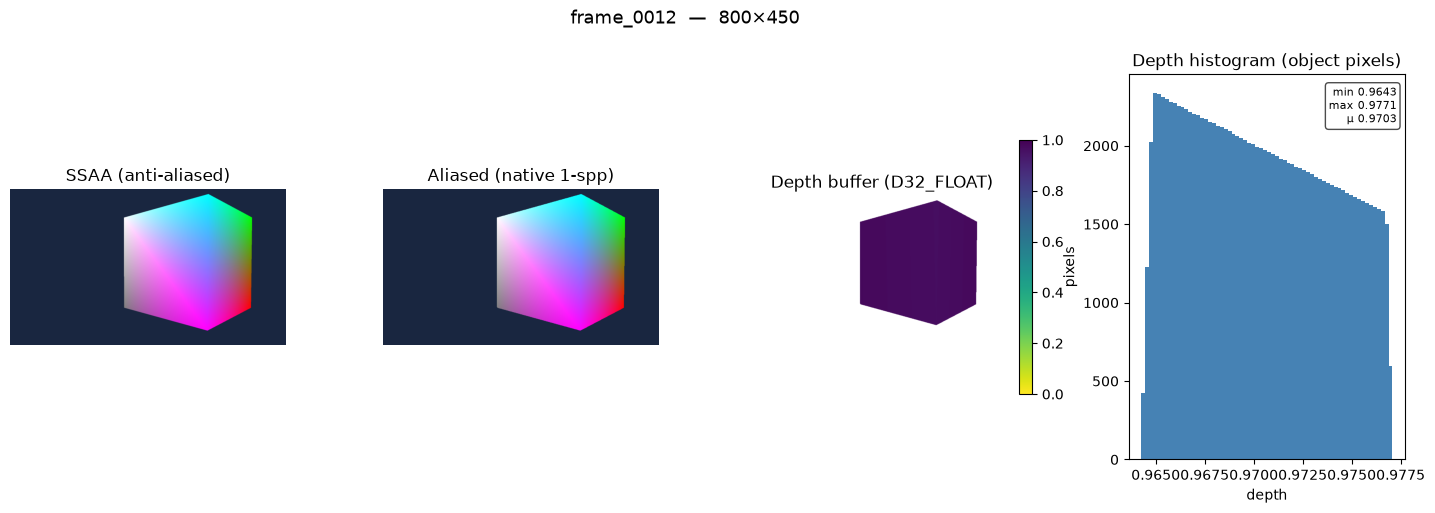

  object pixels: 121,382 / 360,000  (33.7%)


In [9]:
# show the most recent capture
if frames:
    show_frame(frames[0])
else:
    print("No captures found. Press C in the app to capture a frame.")

C:\Users\magno\AppData\Local\Temp\ipykernel_14044\1128938162.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


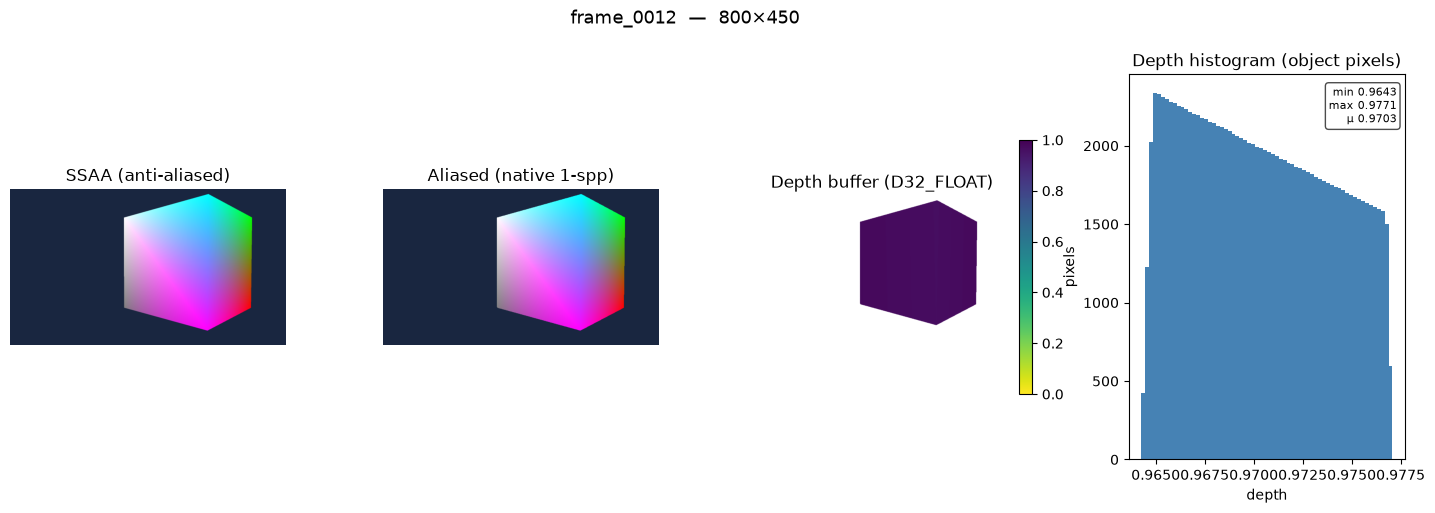

  object pixels: 121,382 / 360,000  (33.7%)


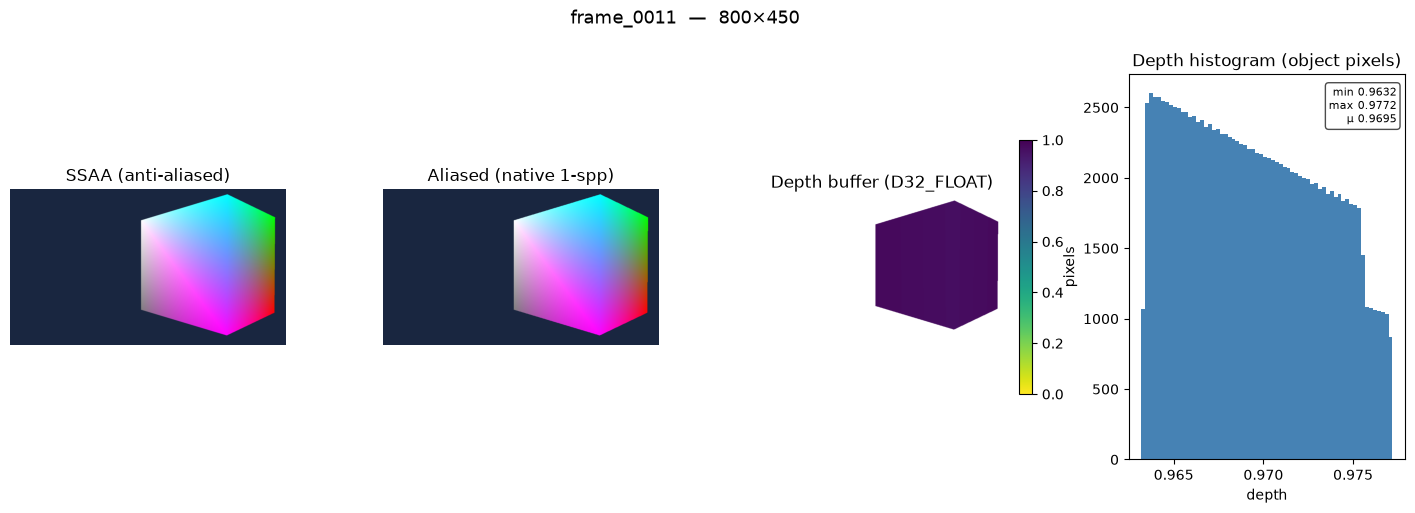

  object pixels: 130,657 / 360,000  (36.3%)


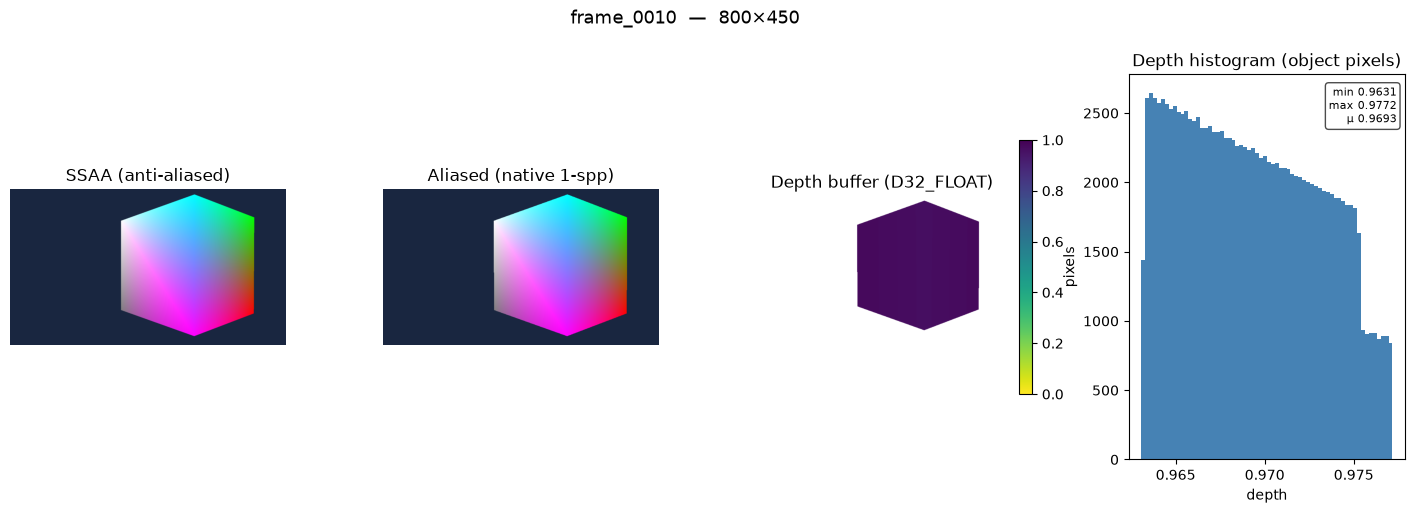

  object pixels: 130,635 / 360,000  (36.3%)


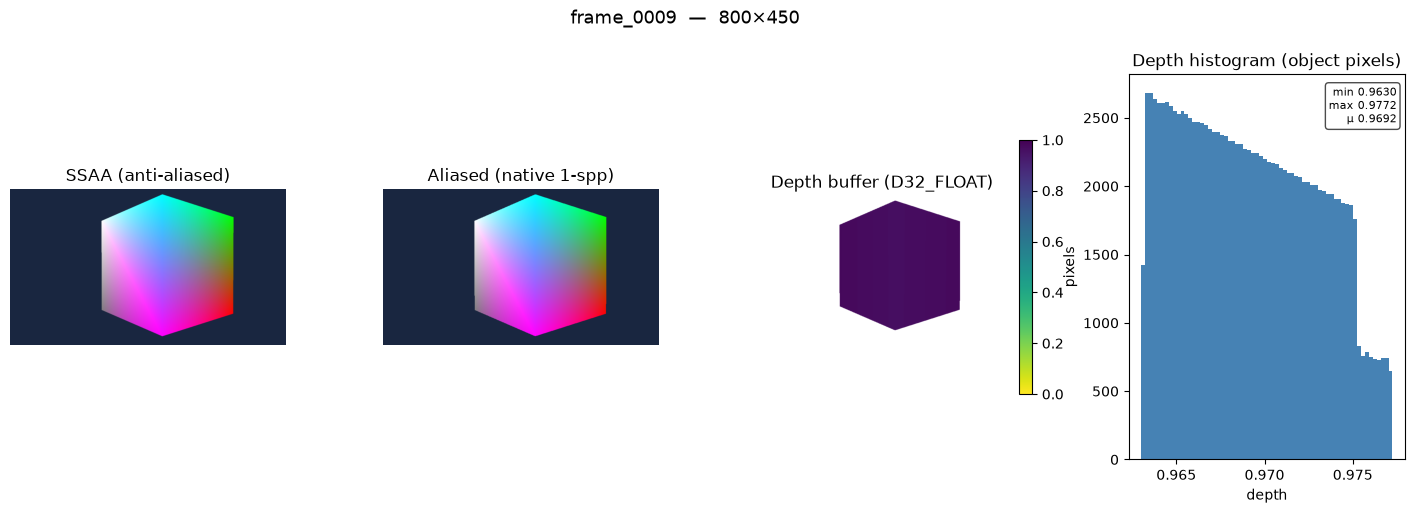

  object pixels: 129,932 / 360,000  (36.1%)


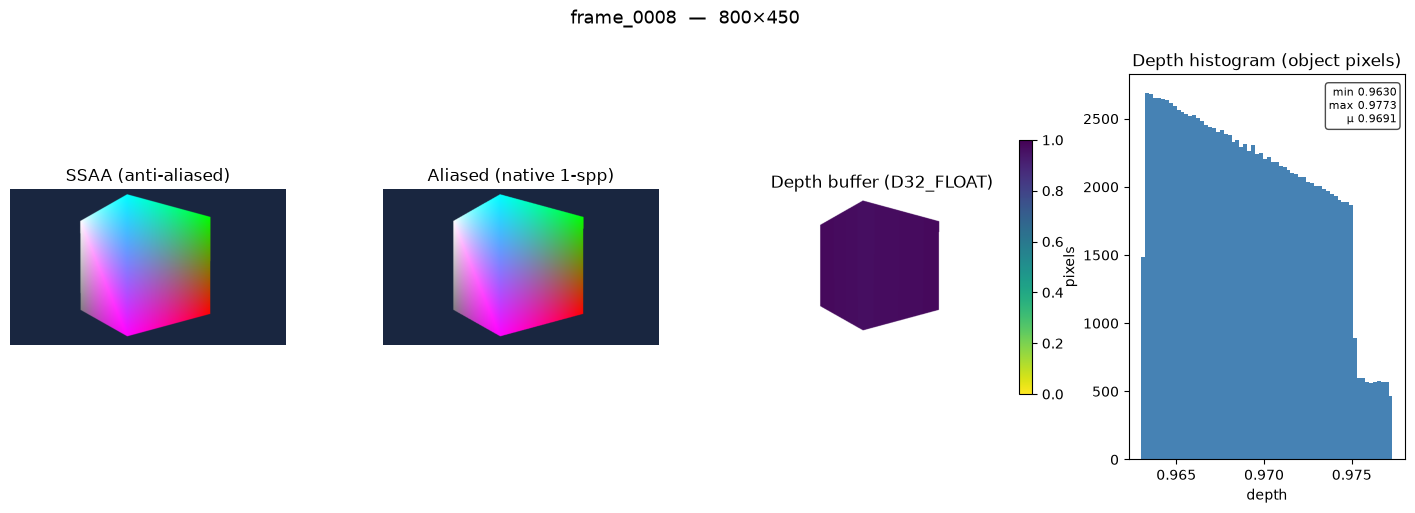

  object pixels: 128,554 / 360,000  (35.7%)


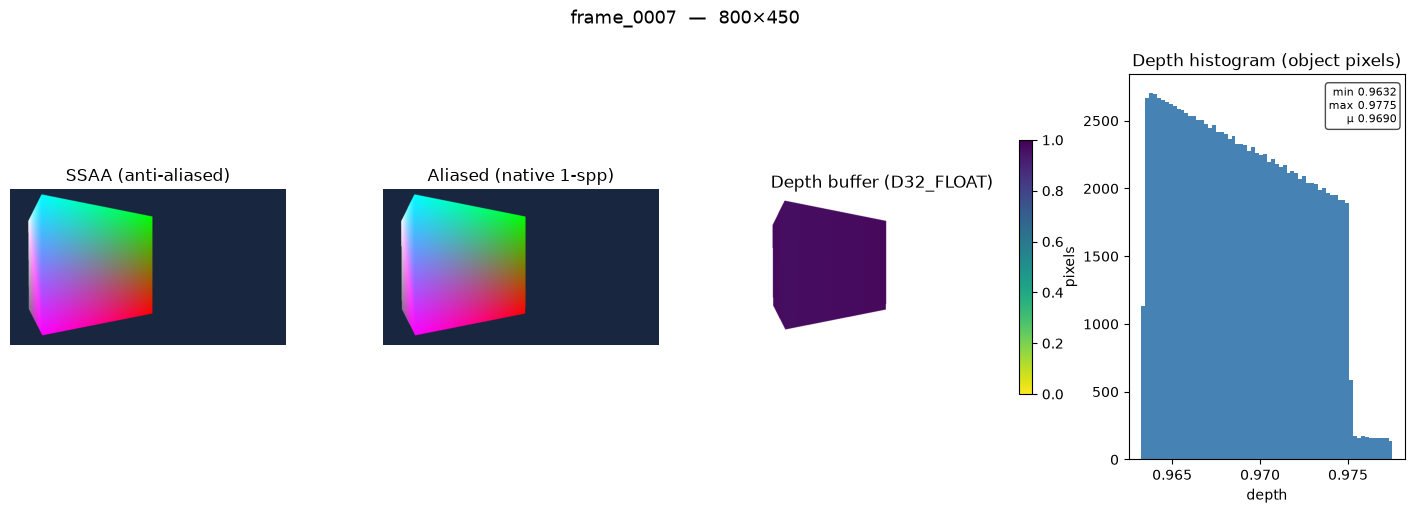

  object pixels: 123,241 / 360,000  (34.2%)


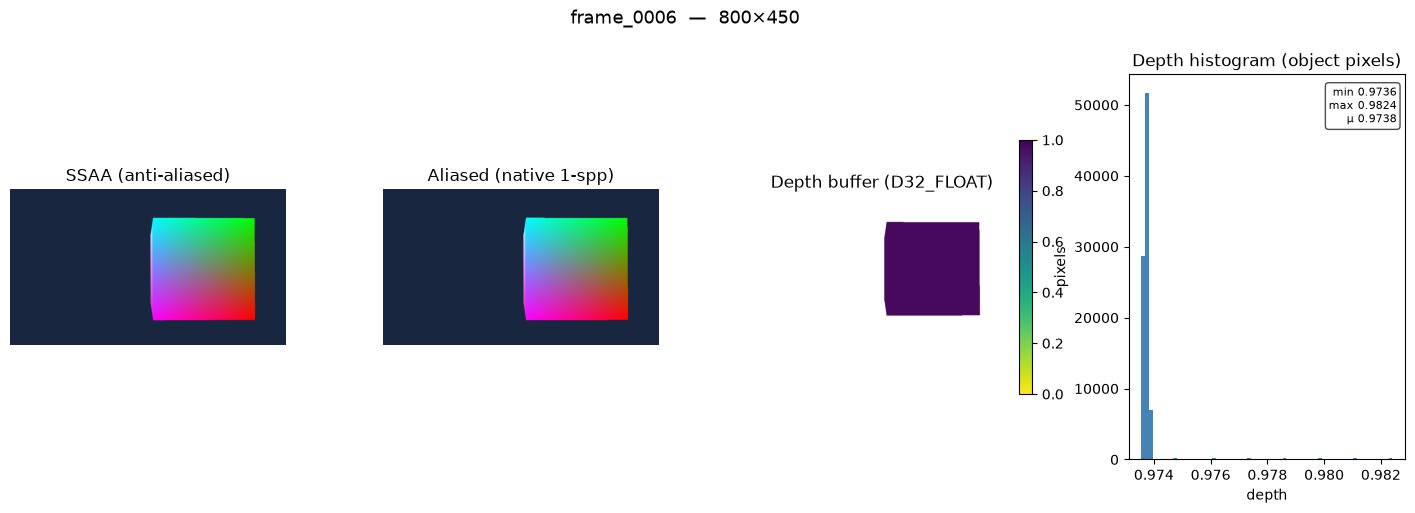

  object pixels: 89,089 / 360,000  (24.7%)


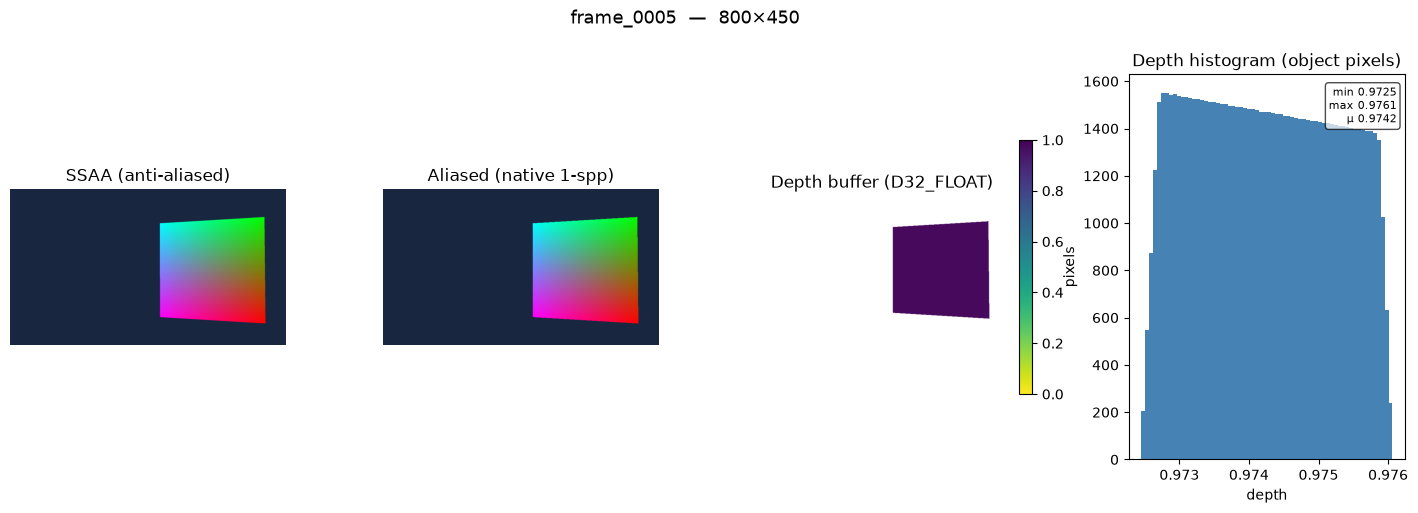

  object pixels: 88,325 / 360,000  (24.5%)


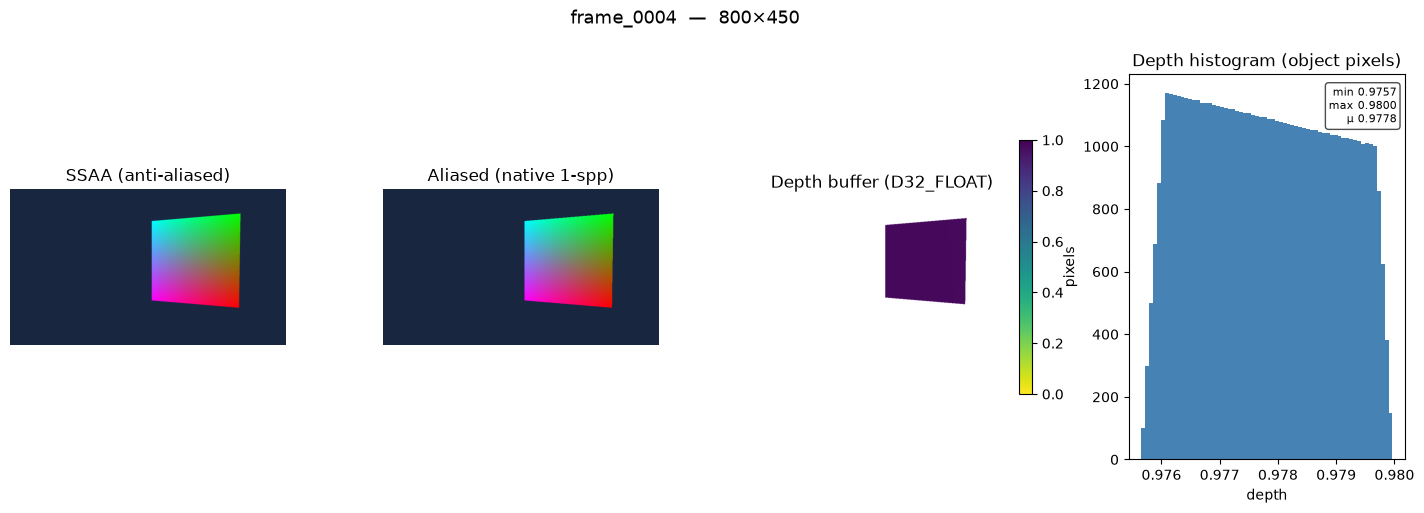

  object pixels: 64,240 / 360,000  (17.8%)


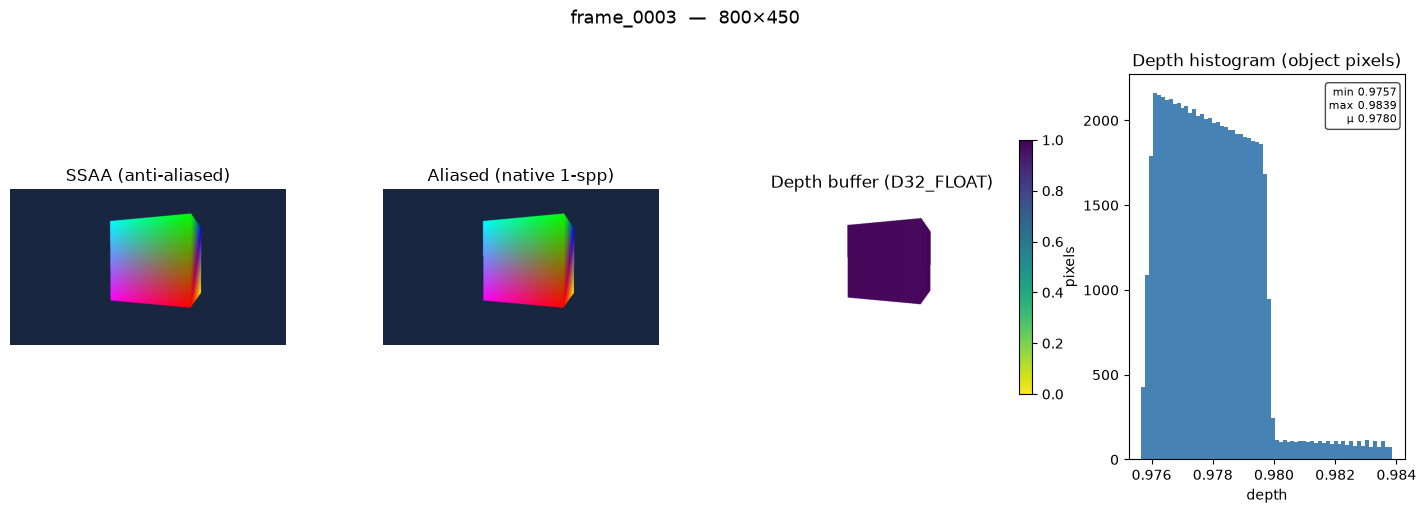

  object pixels: 65,486 / 360,000  (18.2%)


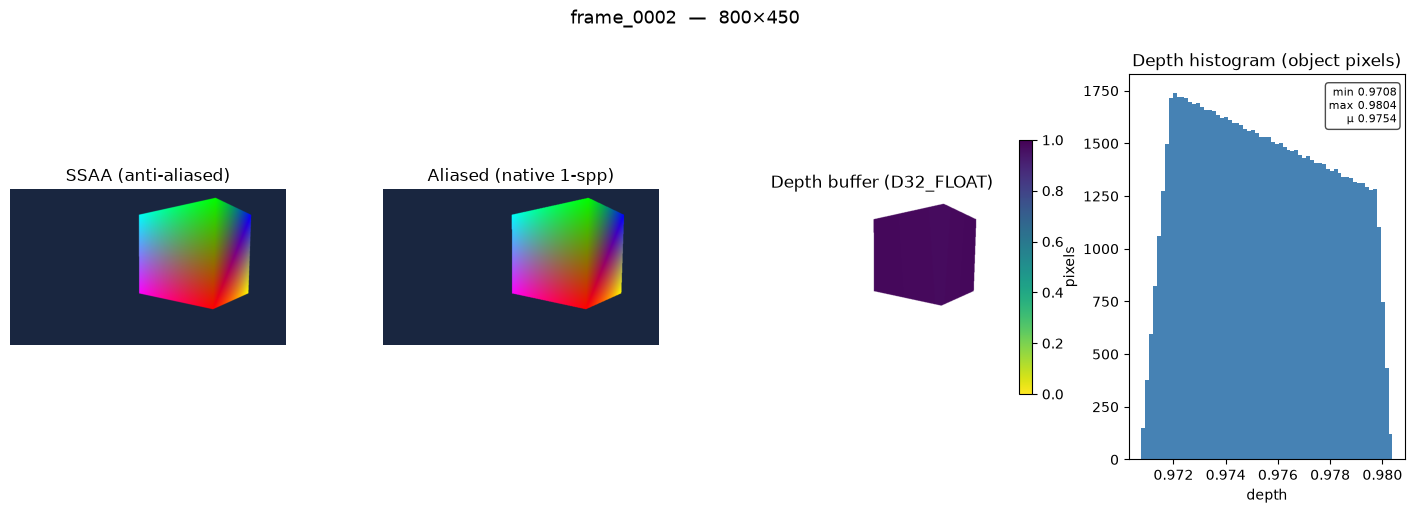

  object pixels: 88,253 / 360,000  (24.5%)


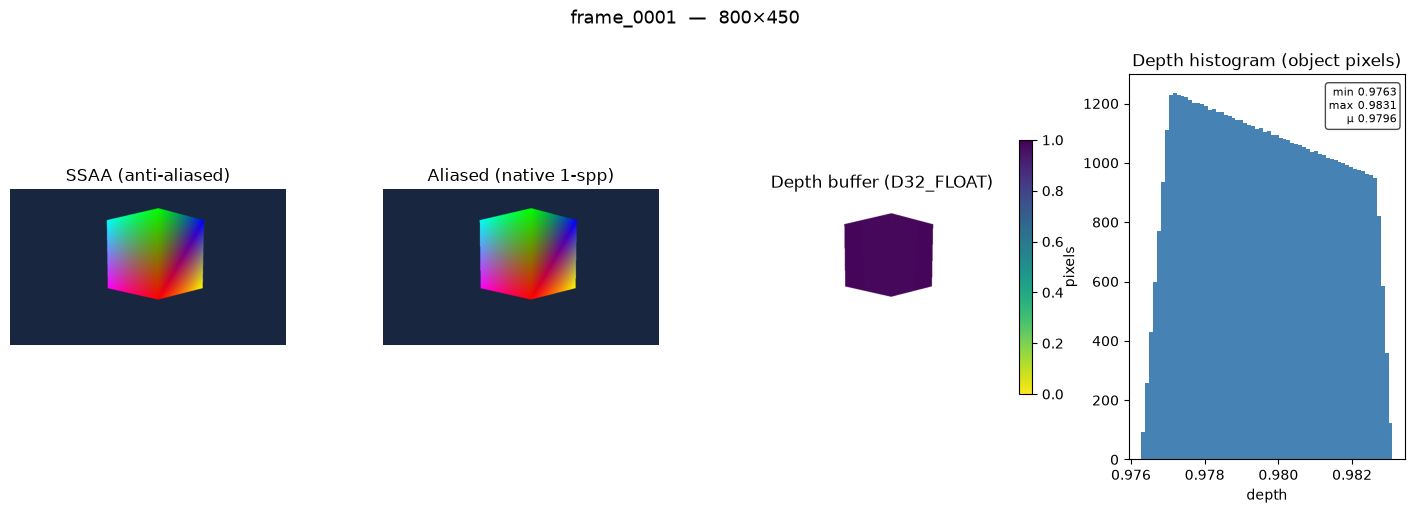

  object pixels: 64,191 / 360,000  (17.8%)


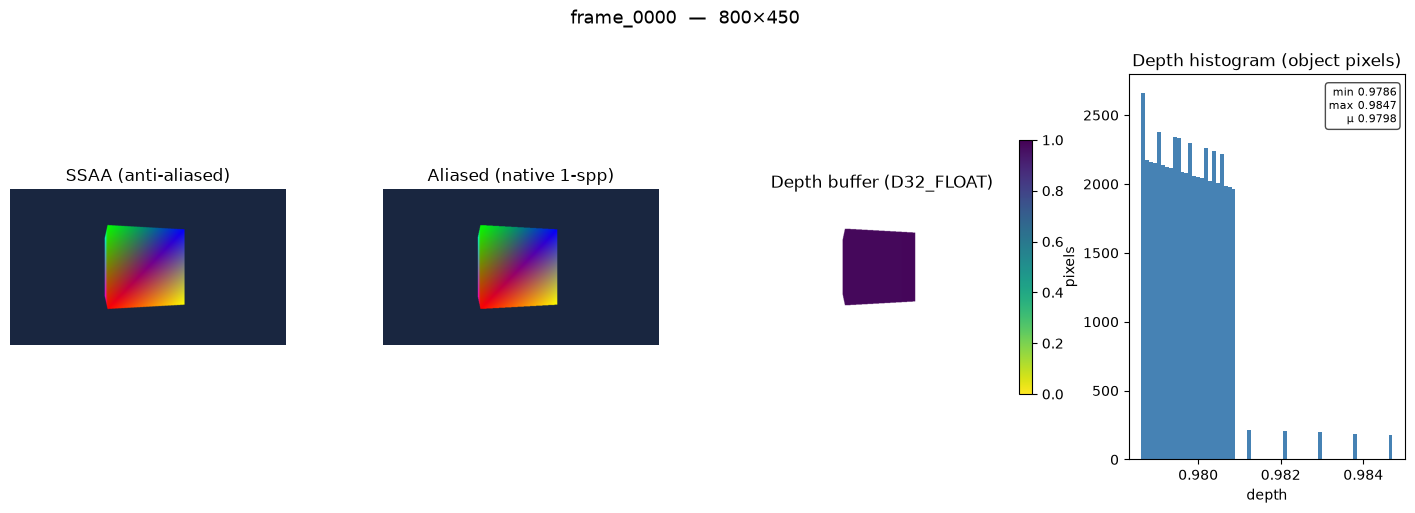

  object pixels: 52,854 / 360,000  (14.7%)


In [10]:
# show ALL captures
for idx in frames:
    show_frame(idx)

In [6]:
# SSAA vs Aliased diff (highlight aliasing edges)
if frames:
    ssaa, aliased, _ = load_frame(frames[0])
    diff = np.abs(ssaa.astype(int) - aliased.astype(int)).mean(axis=2)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].imshow(ssaa);    axes[0].set_title("SSAA");    axes[0].axis("off")
    axes[1].imshow(aliased); axes[1].set_title("Aliased"); axes[1].axis("off")
    im = axes[2].imshow(diff, cmap="hot", vmin=0)
    axes[2].set_title("|SSAA − Aliased| (mean RGB)"); axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    plt.suptitle(f"frame_{frames[0]:04d}  —  aliasing difference map", fontsize=12)
    plt.tight_layout()
    plt.show()
    print(f"  mean diff: {diff.mean():.2f}  max diff: {diff.max():.0f}")